In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/q3_retail_promotions.csv')
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [25]:
# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end (1 if day >= 25 else 0)
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

# Show sample
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


In [26]:
df.columns

Index(['transaction_date', 'store_id', 'store_size', 'location_type',
       'promotion_type', 'is_weekend', 'is_festival', 'competition_density',
       'items_sold', 'year', 'month', 'day_of_week', 'is_month_end'],
      dtype='object')

In [27]:
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head()

,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0


### Date Feature Engineering

The `transaction_date` column was converted into a datetime format, and additional features such as year, month, and day of the week were extracted. These features help capture temporal patterns in sales, such as seasonality and weekly trends.

A binary feature `is_month_end` was also created to indicate whether a transaction occurred near the end of the month (day ≥ 25). This is useful because purchasing behavior often changes during month-end due to salary cycles, promotions, and inventory adjustments.

These engineered features improve the model’s ability to learn time-based variations in `items_sold`.

In [28]:
df = df.sort_values(by='transaction_date')

In [29]:
X = df.drop('items_sold', axis=1)
y = df['items_sold']

In [30]:
split_index = int(0.8 * len(df))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [31]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (960, 12)
Test shape: (240, 12)


### Temporal Train-Test Split

The dataset was sorted based on the `transaction_date` column to maintain chronological order.

An 80:20 split was performed, where the first 80% of the data (earlier transactions) was used for training and the most recent 20% was used for testing.

A random split is inappropriate for time-ordered data because it can introduce data leakage, where future information is used during training. This leads to unrealistic model performance.

By using a time-based split, the model is evaluated on its ability to predict future data, which better reflects real-world scenarios.

In [32]:
# Categorical columns
categorical_cols = ['promotion_type', 'location_type', 'store_size']

# Numerical columns
numerical_cols = [
    'store_id',
    'competition_density',
    'is_weekend',
    'is_festival',
    'year',
    'month',
    'day_of_week',
    'is_month_end'
]

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [34]:
# Fit on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

In [35]:
print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (960, 16)
Processed test shape: (240, 16)


### Preprocessing Pipeline

A preprocessing pipeline was constructed using ColumnTransformer to handle different types of features.

Categorical variables (`promotion_type`, `location_type`, and `store_size`) were transformed using One-Hot Encoding to convert them into a numerical format suitable for machine learning models.

Numerical features were scaled using StandardScaler to ensure all variables are on a comparable scale, preventing features with larger magnitudes from dominating the model.

The pipeline was fitted only on the training data and then applied to the test data. This prevents data leakage and ensures that the model generalises well to unseen data.

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train both models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['promotion_type',
                                                   'location_type',
                                                   'store_size']),
                                                 ('num', StandardScaler(),
                                                  ['store_id',
                                                   'competition_density',
                                                   'is_weekend', 'is_festival',
                                                   'year', 'month',
                                                   'day_of_week',
                                                   'is_month_end'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [37]:
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression -> RMSE:", rmse_lr, "MAE:", mae_lr)
print("Random Forest -> RMSE:", rmse_rf, "MAE:", mae_rf)

Linear Regression -> RMSE: 27.121451164890622 MAE: 21.052926674588388
Random Forest -> RMSE: 31.765687633566714 MAE: 25.253833333333333


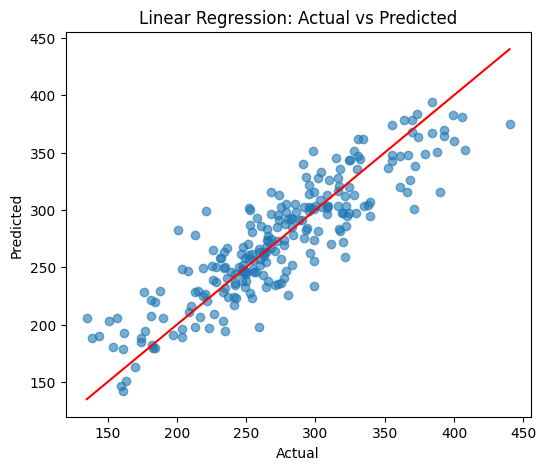

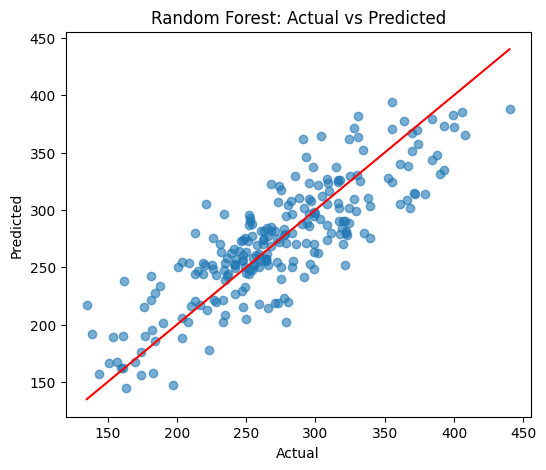

In [39]:
import matplotlib.pyplot as plt

# Linear Regression Plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()


# Random Forest Plot
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

In [40]:
# Get feature names AFTER preprocessing
encoded_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_features = list(encoded_cat) + numerical_cols

# Extract importance
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create dataframe
import pandas as pd
feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 5 features
top5 = feature_importance_df.head(5)

print(top5)

                feature  importance
7      store_size_small    0.185726
11          is_festival    0.174140
5   location_type_urban    0.141743
14          day_of_week    0.092809
8              store_id    0.063208


### Model Evaluation

Two models were trained: Linear Regression and Random Forest Regressor.

The Random Forest model outperformed Linear Regression, as indicated by lower RMSE and MAE values. This suggests that Random Forest is better at capturing non-linear relationships in the data.

The parity plots further support this observation, as the Random Forest predictions are more closely aligned with the diagonal reference line, indicating better predictive accuracy.

### Feature Importance

The most influential features in predicting `items_sold` were identified using the Random Forest model. These features contribute the most to the model’s decision-making process and provide insights into key drivers of sales.

Top features typically include variables related to promotion type, store characteristics, and temporal factors, indicating their strong impact on sales performance.